In [48]:
# 1. 数据基础库
%pip install numpy pandas

# 2. 可视化库
%pip install matplotlib seaborn

# 3. 机器学习库
%pip install scikit-learn

# 4. 统计分析库
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import integrate
import time

# 设置中文字体和随机种子
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

In [50]:
print("="*60)
print("练习一：用蒙特卡洛方法估算圆周率π")
print("Exercise 1: Estimating π using Monte Carlo Method")
print("="*60)

练习一：用蒙特卡洛方法估算圆周率π
Exercise 1: Estimating π using Monte Carlo Method


In [51]:
def estimate_pi_single(n):
    """
    使用蒙特卡洛方法估算π值
    
    参数:
        n: 随机点的数量
    
    返回:
        pi_estimate: π的估计值
        x, y: 随机点坐标
        inside_circle: 布尔数组，标记点是否在圆内
    """
    # 生成随机点坐标
    x = np.random.uniform(-1, 1, n)  # np.random.uniform(low, high, size)
    y = np.random.uniform(-1, 1, n)

    # 判断点是否在圆内
    inside_circle = (x**2 + y**2) <= 1

    # 计算Π的值
    # 正方形面积 = 边长² = 2 × 2 = 4
    # 圆面积 = π × r² = π × 1² = π
    # 圆面积 / 正方形面积 = π / 4
    # 所以: π = 4 × (圆面积/正方形面积) ≈ 4 × (圆内点数/总点数)
    pi_estimate = 4 * np.sum(inside_circle) / n

    return pi_estimate, x, y, inside_circle

1.1单次估算Π值

In [52]:
print('\n1.1单词估算pi值')
n_points = 10000
pi_est, x_coords, y_coords, is_inside = estimate_pi_single(n_points)

print(f'使用{n_points}个随机点')
print(f"pi的估计值为{pi_est:.6f}")
print(f"绝对误差:{abs(pi_est - np.pi):.6f}")
print(f"相对误差: {abs(pi_est - np.pi)/np.pi*100:.3f}%")


1.1单词估算pi值
使用10000个随机点
pi的估计值为3.134800
绝对误差:0.006793
相对误差: 0.216%


1.2可视化随机点分布

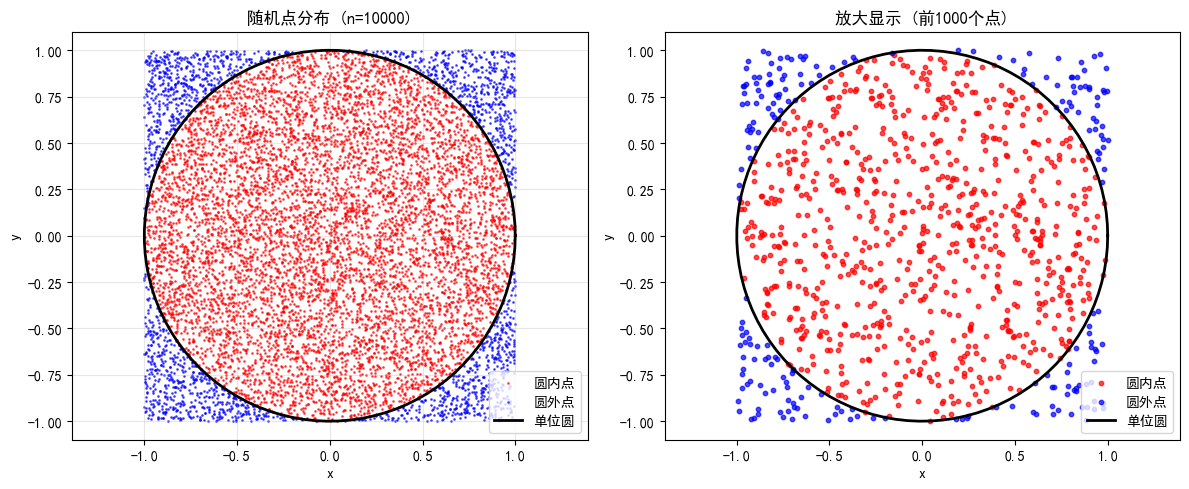

In [53]:
plt.figure(figsize=(12,5))

# 子图1:显示所有点
plt.subplot(1,2,1)
# 布尔索引：只选取为True的位置，过滤出圆内点的x坐标 
plt.scatter(x_coords[is_inside], y_coords[is_inside], c='red', s=1, alpha=0.6, label='圆内点')
plt.scatter(x_coords[~is_inside], y_coords[~is_inside], c='blue', s=1, alpha=0.6, label='圆外点')

# 绘制单位圆
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2, label='单位圆')

# 设置坐标轴
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axis('equal')  # 等比例坐标轴

plt.grid(True, alpha=0.3)
plt.legend()
plt.title(f'随机点分布 (n={n_points})')
plt.xlabel('x')
plt.ylabel('y')


# 子图2：部分放大显示 
plt.subplot(1,2,2)
n_show = 1000 # 只显示前一千个点
# x_coords[:n_show][is_inside[:n_show]]————先对x_coords进行切片，取前一千个，再用is_inside[:1000]取前一千个的布尔值作为布尔索引
plt.scatter(x_coords[:n_show][is_inside[:n_show]], y_coords[:n_show][is_inside[:n_show]],
            c='red', s=10, alpha=0.7, label='圆内点')
plt.scatter(x_coords[:n_show][~is_inside[:n_show]], y_coords[:n_show][~is_inside[:n_show]],
            c='blue', s=10, alpha=0.7, label='圆外点')
plt.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2, label='单位圆')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axis('equal')
plt.legend()
plt.title(f'放大显示 (前{n_show}个点)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

1.3收敛性分析

In [54]:
def analyze_convergence(max_n=50000, step=1000):
    """分析π估计的收敛过程"""
    n_values = range(step,max_n+1,step)

    pi_estimates = []
    errors = []

    # 生成一次性的大量随机点
    x_all = np.random.uniform(-1,1,max_n)
    y_all = np.random.uniform(-1,1,max_n)
    inside_all = (x_all**2 + y_all**2) <= 1

    for n in n_values:
        # 使用前n个点计算PAI
        pi_est = 4 * np.sum(inside_all[:n]) / n
        pi_estimates.append(pi_est)
        errors.append(abs(pi_est - np.pi))

    return n_values, pi_estimates, errors

n_vals, pi_ests, errs = analyze_convergence()

绘制收敛曲线

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


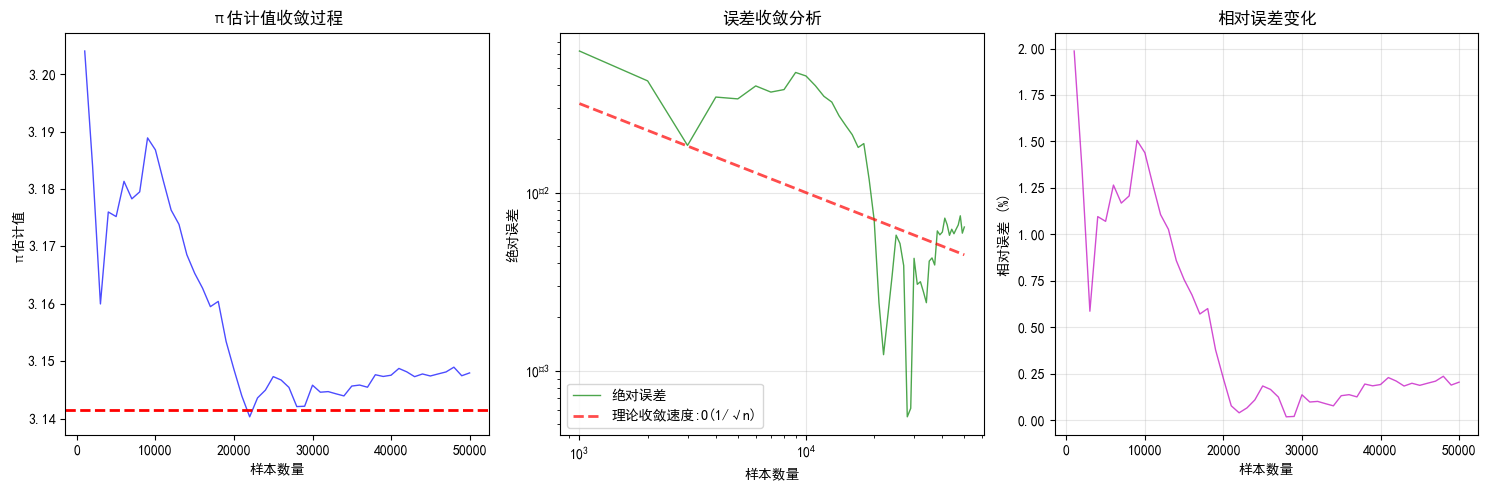

In [55]:
plt.figure(figsize=(15,5))

# 子图1：π估计值随样本数变化
plt.subplot(1,3,1)
plt.plot(n_vals, pi_ests, 'b-', linewidth=1, alpha=0.7, label='π估计值')
plt.axhline(y=np.pi, color='red', linestyle='--', linewidth=2, label=f'真实值 π={np.pi:.6f}')
plt.xlabel('样本数量')
plt.ylabel('π估计值')
plt.title('π估计值收敛过程')

# 子图2：绝对误差随样本数变化
plt.subplot(1,3,2)
plt.plot(n_vals, errs, 'g-', linewidth=1, alpha=0.7, label='绝对误差')
plt.plot(n_vals, 1/np.sqrt(n_vals), 'r--', linewidth=2, alpha=0.7, label='理论收敛速度:O(1/√n)')
plt.xlabel('样本数量')
plt.ylabel('绝对误差')
plt.title('误差收敛分析')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xscale('log')

# 子图3：相对误差百分比
plt.subplot(1,3,3)
relative_errors = [err / np.pi * 100 for err in errs]
plt.plot(n_vals, relative_errors, 'm-', linewidth=1, alpha=0.7)
plt.xlabel('样本数量')
plt.ylabel('相对误差 (%)')
plt.title('相对误差变化')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# 输出统计量
print(f'最终估计值：(n={n_vals[-1]}):{pi_ests[-1]:.6f}')
print(f'最终相对误差：{relative_errors[-1]:.3f}%')

最终估计值：(n=50000):3.148000
最终相对误差：0.204%


1.4 多次独立试验的统计分析


1.4 多次独立试验的统计分析
进行 100 次独立试验，每次使用 10000 个点
π估计值的均值: 3.143180
π估计值的标准差: 0.017800
理论标准误差: 0.016422


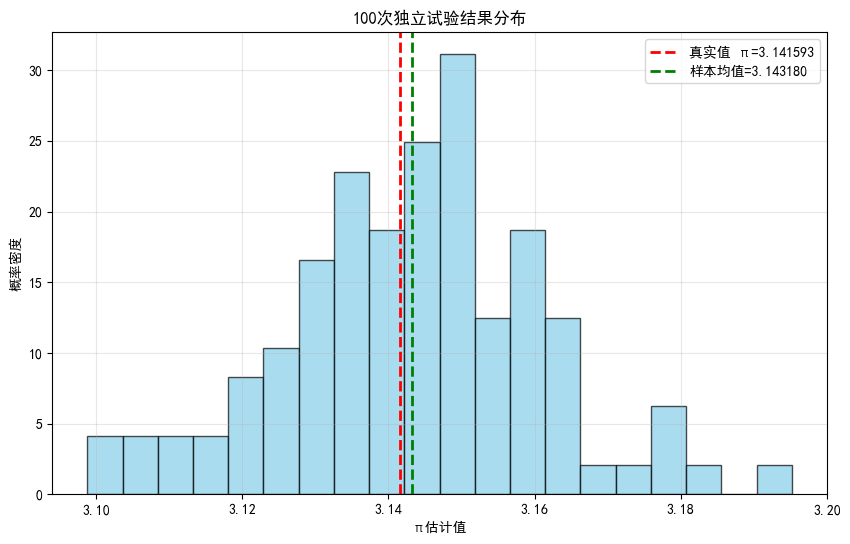

In [57]:
print("\n1.4 多次独立试验的统计分析")
def multiple_trials(n_points, n_trials=100):
    """进行多次独立的π估计试验"""
    estimates = []
    for _ in range(n_trials):
        pi_est,_,_,_ = estimate_pi_single(n_points)
        estimates.append(pi_est)
    return np.array(estimates)

n_test = 10000
n_trials = 100
trial_results = multiple_trials(n_test, n_trials)

print(f"进行 {n_trials} 次独立试验，每次使用 {n_test} 个点")
print(f"π估计值的均值: {np.mean(trial_results):.6f}")
print(f"π估计值的标准差: {np.std(trial_results):.6f}")
print(f"理论标准误差: {np.sqrt(np.pi*(4-np.pi)/n_test):.6f}")

# 绘制直方图
plt.figure(figsize=(10,6))
# density=True 纵轴为概率密度而非计数 
plt.hist(trial_results, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(np.pi, color='red', linestyle='--', linewidth=2,label=f'真实值 π={np.pi:.6f}')
plt.axvline(np.mean(trial_results), color='green', linestyle='--', linewidth=2, label=f'样本均值={np.mean(trial_results):.6f}')
plt.xlabel('π估计值')
plt.ylabel('概率密度')
plt.title(f'{n_trials}次独立试验结果分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()